# Experiment 03 – Correlation, Distance Measures and Data Preprocessing
## Aim
To implement correlation analysis, distance measures, and basic data preprocessing techniques on the Pima Indians Diabetes Dataset to identify relationships and prepare data for further analysis.

## Objectives

1. To apply correlation and distance measures to analyze relationships and similarities among data observations.
2. To implement basic data preprocessing techniques to prepare a dataset for statistical analysis and machine learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances
from sklearn.metrics.pairwise import cosine_distances
sns.set_theme(style="whitegrid")

In [2]:
from google.colab import files
uploaded = files.upload()
df = pd.read_csv("diabetes.csv")
print("Dataset loaded successfully.")
display(df.head())

Saving diabetes.csv to diabetes.csv
Dataset loaded successfully.


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1


In [3]:
print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())
print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (768, 9)

Column Names:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

Missing Values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


## Identifying Invalid Values


In [4]:
medical_columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]
zero_counts = (df[medical_columns] == 0).sum()
print("Zero values in selected medical attributes:")
display(zero_counts)

Zero values in selected medical attributes:


,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0


In [5]:
df_processed = df.copy()
df_processed[medical_columns] = (
    df_processed[medical_columns].replace(0, np.nan)
)
print("Missing values after replacing invalid zeros:")
display(df_processed[medical_columns].isnull().sum())

Missing values after replacing invalid zeros:


,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0


## Handling Missing Values


In [6]:
imputer = SimpleImputer(strategy="median")
df_processed[medical_columns] = imputer.fit_transform(
    df_processed[medical_columns]
)
print("Missing values after median imputation:")
display(df_processed.isnull().sum())

Missing values after median imputation:


,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


## Correlation Analysis

In [7]:
correlation_matrix = df_processed.corr(numeric_only=True)
display(correlation_matrix)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.130155,0.209151,0.089028,0.058767,0.023890,-0.033523,0.544341,0.221898
Glucose,0.130155,1.000000,0.225141,0.229289,0.490015,0.236171,0.138353,0.268910,0.495990
BloodPressure,0.209151,0.225141,1.000000,0.199349,0.070128,0.286399,-0.001443,0.325135,0.174469
SkinThickness,0.089028,0.229289,0.199349,1.000000,0.200129,0.566086,0.106280,0.129537,0.295138
Insulin,0.058767,0.490015,0.070128,0.200129,1.000000,0.238443,0.146878,0.123629,0.377081
BMI,0.023890,0.236171,0.286399,0.566086,0.238443,1.000000,0.152771,0.027849,0.315577
DiabetesPedigreeFunction,-0.033523,0.138353,-0.001443,0.106280,0.146878,0.152771,1.000000,0.033561,0.173844
Age,0.544341,0.268910,0.325135,0.129537,0.123629,0.027849,0.033561,1.000000,0.238356
Outcome,0.221898,0.495990,0.174469,0.295138,0.377081,0.315577,0.173844,0.238356,1.000000


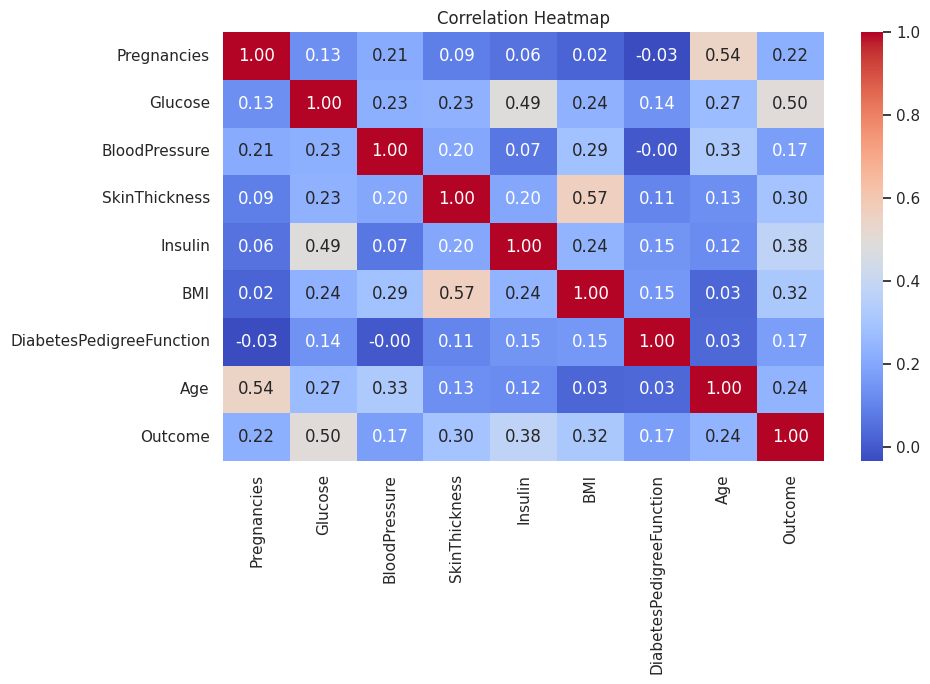

In [8]:
plt.figure(figsize=(10, 7))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [9]:
corr_values = correlation_matrix.copy()
np.fill_diagonal(corr_values.values, np.nan)
max_index = np.unravel_index(
    np.nanargmax(np.abs(corr_values.values)),
    corr_values.shape
)
var1 = correlation_matrix.index[max_index[0]]
var2 = correlation_matrix.columns[max_index[1]]
value = correlation_matrix.iloc[max_index]
print(f"Strongest absolute correlation: {var1} and {var2}")
print(f"Correlation coefficient: {value:.4f}")

Strongest absolute correlation: SkinThickness and BMI
Correlation coefficient: 0.5661


## Distance Measures

In [10]:
distance_features = medical_columns
X = df_processed[distance_features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Original data:")
display(X.head())
print("\nStandardized data:")
display(pd.DataFrame(X_scaled, columns=distance_features).head())

Original data:


,Glucose,BloodPressure,SkinThickness,Insulin,BMI
0,148.0,72.0,35.0,169.5,33.6
1,85.0,66.0,29.0,102.5,26.6
2,183.0,64.0,32.0,169.5,23.3
3,89.0,66.0,23.0,94.0,28.1
4,137.0,40.0,35.0,168.0,43.1



Standardized data:


,Glucose,BloodPressure,SkinThickness,Insulin,BMI
0,0.864625,-0.032180,0.665181,0.311604,0.169483
1,-1.204727,-0.528124,-0.010112,-0.440843,-0.848549
2,2.014265,-0.693438,0.327535,0.311604,-1.328478
3,-1.073339,-0.528124,-0.685405,-0.536303,-0.630399
4,0.503310,-2.677212,0.665181,0.294758,1.551096


In [11]:
observation_1 = X.iloc[0].values.reshape(1, -1)
observation_2 = X.iloc[1].values.reshape(1, -1)
scaled_observation_1 = X_scaled[0].reshape(1, -1)
scaled_observation_2 = X_scaled[1].reshape(1, -1)
euclidean_distance = pairwise_distances(
    scaled_observation_1,
    scaled_observation_2,
    metric="euclidean"
)[0][0]
manhattan_distance = pairwise_distances(
    scaled_observation_1,
    scaled_observation_2,
    metric="manhattan"
)[0][0]
cosine_distance = cosine_distances(
    scaled_observation_1,
    scaled_observation_2
)[0][0]
print("Distance Measures Between Observation 1 and Observation 2")
print(f"Euclidean Distance : {euclidean_distance:.4f}")
print(f"Manhattan Distance : {manhattan_distance:.4f}")
print(f"Cosine Distance    : {cosine_distance:.4f}")

Distance Measures Between Observation 1 and Observation 2
Euclidean Distance : 2.5665
Manhattan Distance : 5.0111
Cosine Distance    : 1.7033


In [12]:
before_after = pd.DataFrame({
    "Before Mean": X.mean(),
    "Before Std": X.std(),
    "After Mean": X_scaled.mean(axis=0),
    "After Std": X_scaled.std(axis=0)
}, index=distance_features)
display(before_after)

,Before Mean,Before Std,After Mean,After Std
Glucose,121.677083,30.464161,1.480297e-16,1.0
BloodPressure,72.389323,12.106039,-3.978299e-16,1.0
SkinThickness,29.089844,8.890820,8.095376e-18,1.0
Insulin,141.753906,89.100847,-3.469447e-18,1.0
BMI,32.434635,6.880498,1.318390e-16,1.0


In [13]:
raw_euclidean = pairwise_distances(
    observation_1,
    observation_2,
    metric="euclidean"
)[0][0]
raw_manhattan = pairwise_distances(
    observation_1,
    observation_2,
    metric="manhattan"
)[0][0]
raw_cosine = cosine_distances(
    observation_1,
    observation_2
)[0][0]
distance_comparison = pd.DataFrame({
    "Distance Measure": [
        "Euclidean",
        "Manhattan",
        "Cosine"
    ],
    "Before Standardization": [
        raw_euclidean,
        raw_manhattan,
        raw_cosine
    ],
    "After Standardization": [
        euclidean_distance,
        manhattan_distance,
        cosine_distance
    ]
})
display(distance_comparison)

,Distance Measure,Before Standardization,After Standardization
0,Euclidean,92.622891,2.566468
1,Manhattan,149.000000,5.011066
2,Cosine,0.012561,1.703309


## Conclusion

Correlation analysis, distance measures, and data preprocessing techniques were implemented on the Pima Indians Diabetes Dataset. Correlation analysis was used to identify relationships between variables, while Euclidean, Manhattan, and Cosine distance measures were used to quantify similarity and dissimilarity between observations. Invalid values were handled using median imputation, and standardization was applied to make the data more suitable for distance-based analysis.